In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

# Full path to your CSV file
data_path = r"C:\Users\Prathap\Desktop\Infosys Project\SentinelNet\Dataset\CICIDS\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"

# Load CSV
df = pd.read_csv(data_path)

print("Shape:", df.shape)
print(df.head())

Shape: (225745, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0              54865               3                   2   
1              55054             109                   1   
2              55055              52                   1   
3              46236              34                   1   
4              54863               3                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        1                            6   
2                        1                            6   
3                        1                            6   
4                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       6   
1                             6                       6   
2                             6                       6   
3                           

In [5]:
print(df.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [8]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()

In [9]:
if "Timestamp" in df.columns:
    df = df.drop(columns=["Timestamp"])

df = df.replace([np.inf, -np.inf], np.nan).dropna()

df["binary_label"] = df["Label"].apply(lambda x: "Benign" if x == "BENIGN" else "Attack")

X = df.drop(columns=["Label", "binary_label"])
y_bin = df["binary_label"]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [col for col in X.columns if col not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

X_train, X_test, y_train_bin, y_test_bin = train_test_split(
    X, y_bin, test_size=0.3, random_state=42, stratify=y_bin
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "AdaBoost": AdaBoostClassifier()
}

def evaluate(true, pred):
    return (
        accuracy_score(true, pred),
        precision_score(true, pred, average="weighted", zero_division=0),
        recall_score(true, pred, average="weighted", zero_division=0),
        f1_score(true, pred, average="weighted", zero_division=0),
    )

===== Binary Classification (Benign vs Attack) =====

🔹 Training Logistic Regression ...

Logistic Regression
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00     38408
      Benign       1.00      1.00      1.00     29306

    accuracy                           1.00     67714
   macro avg       1.00      1.00      1.00     67714
weighted avg       1.00      1.00      1.00     67714



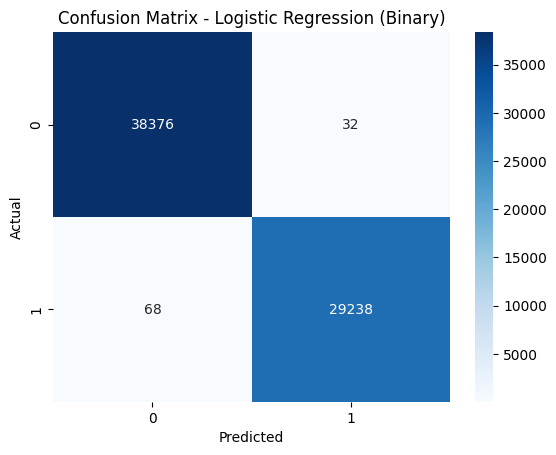


🔹 Training KNN ...

KNN
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00     38408
      Benign       1.00      1.00      1.00     29306

    accuracy                           1.00     67714
   macro avg       1.00      1.00      1.00     67714
weighted avg       1.00      1.00      1.00     67714



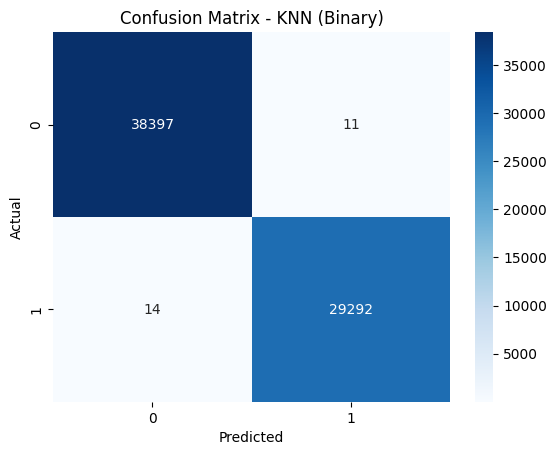


🔹 Training Decision Tree ...

Decision Tree
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00     38408
      Benign       1.00      1.00      1.00     29306

    accuracy                           1.00     67714
   macro avg       1.00      1.00      1.00     67714
weighted avg       1.00      1.00      1.00     67714



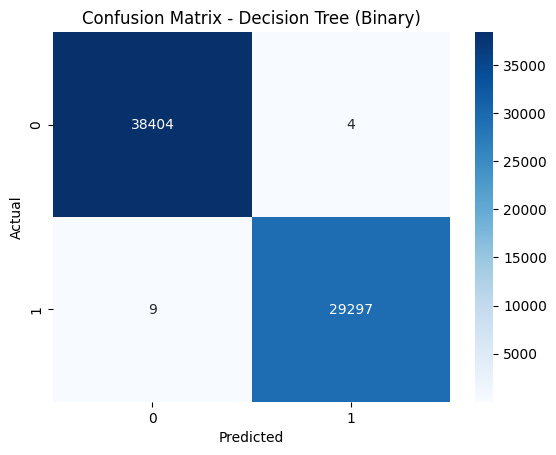


🔹 Training Random Forest ...

Random Forest
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00     38408
      Benign       1.00      1.00      1.00     29306

    accuracy                           1.00     67714
   macro avg       1.00      1.00      1.00     67714
weighted avg       1.00      1.00      1.00     67714



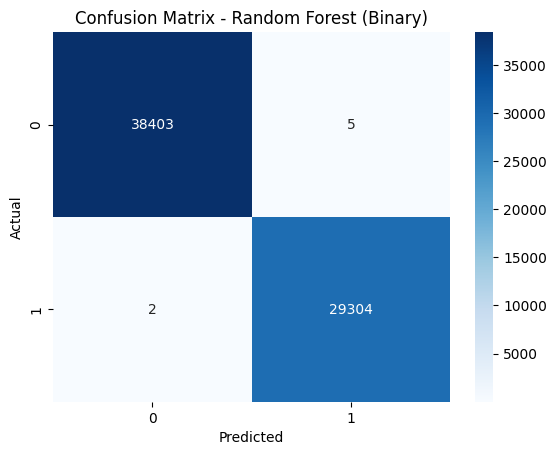


🔹 Training SVM ...

SVM
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00     38408
      Benign       1.00      1.00      1.00     29306

    accuracy                           1.00     67714
   macro avg       1.00      1.00      1.00     67714
weighted avg       1.00      1.00      1.00     67714



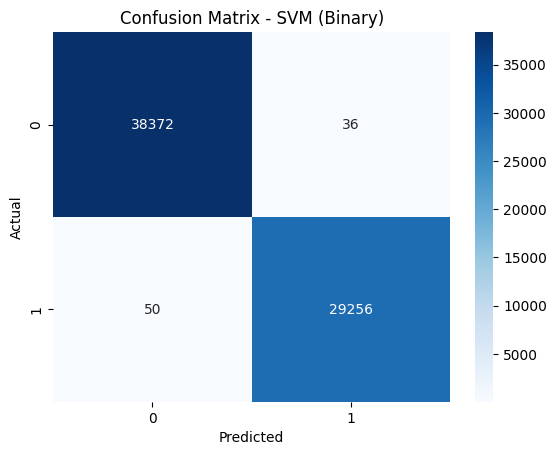


🔹 Training AdaBoost ...

AdaBoost
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00     38408
      Benign       1.00      1.00      1.00     29306

    accuracy                           1.00     67714
   macro avg       1.00      1.00      1.00     67714
weighted avg       1.00      1.00      1.00     67714



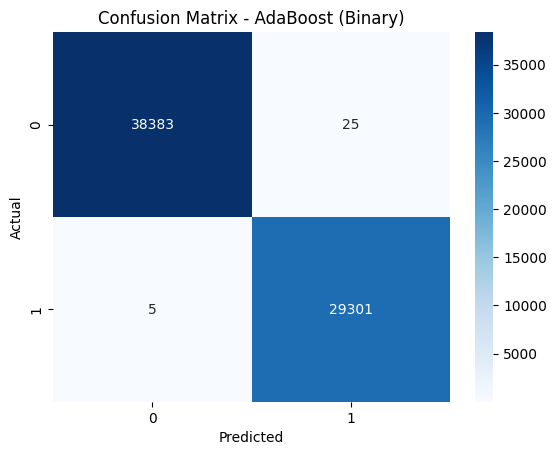


Binary Classification Summary:
                 Model  Accuracy  Precision    Recall        F1
3        Random Forest  0.999897   0.999897  0.999897  0.999897
2        Decision Tree  0.999808   0.999808  0.999808  0.999808
1                  KNN  0.999631   0.999631  0.999631  0.999631
5             AdaBoost  0.999557   0.999557  0.999557  0.999557
4                  SVM  0.998730   0.998730  0.998730  0.998730
0  Logistic Regression  0.998523   0.998524  0.998523  0.998523


In [11]:
print("===== Binary Classification (Benign vs Attack) =====")
summary = []

for name, model in models.items():
    print(f"\n🔹 Training {name} ...")
    model.fit(X_train_proc, y_train_bin)
    y_pred = model.predict(X_test_proc)

    # Metrics
    acc, prec, rec, f1 = evaluate(y_test_bin, y_pred)
    summary.append([name, acc, prec, rec, f1])

    print(f"\n{name}")
    print(classification_report(y_test_bin, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test_bin, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name} (Binary)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Summary table
summary_df = pd.DataFrame(summary, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
print("\nBinary Classification Summary:")
print(summary_df.sort_values(by="Accuracy", ascending=False))
